Initial Graph


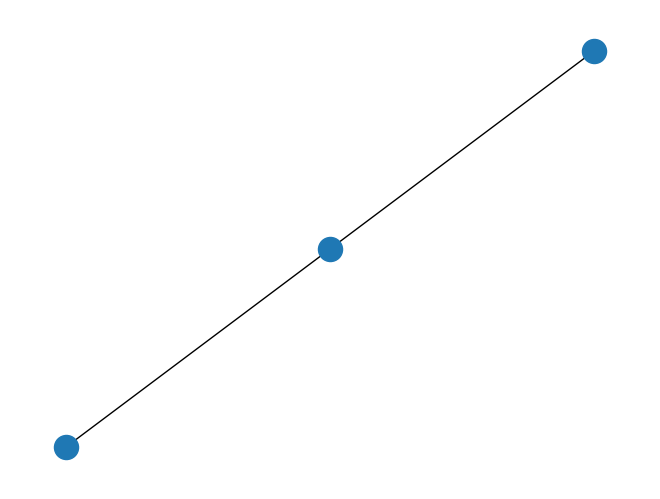

Step: 1


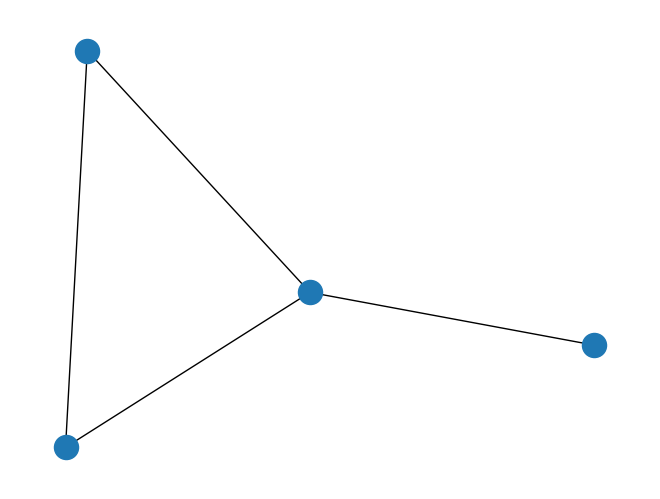

Step: 2


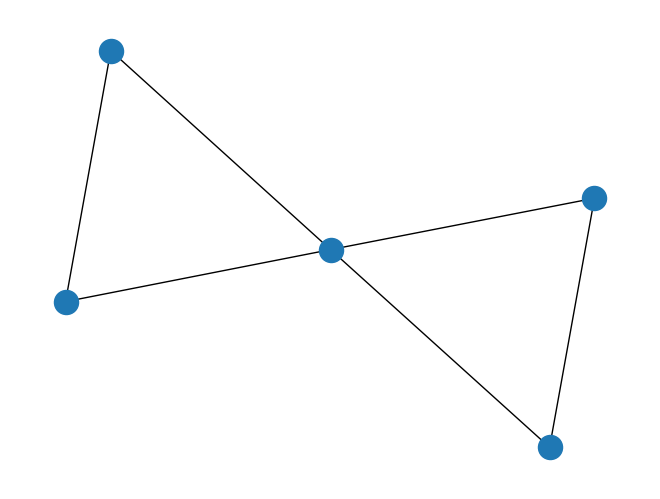

Step: 3


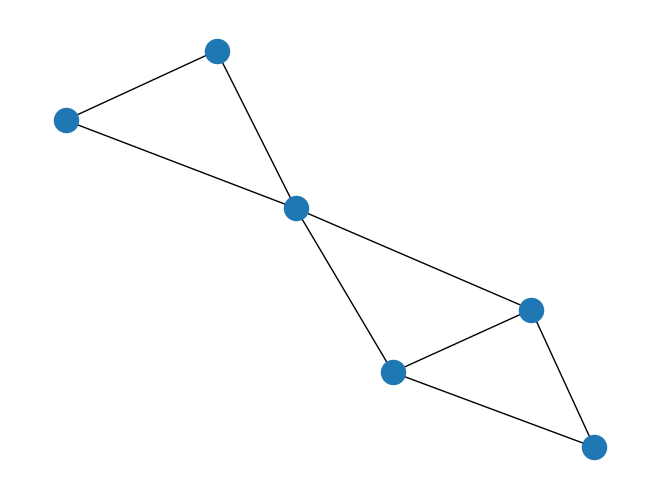

Step: 4


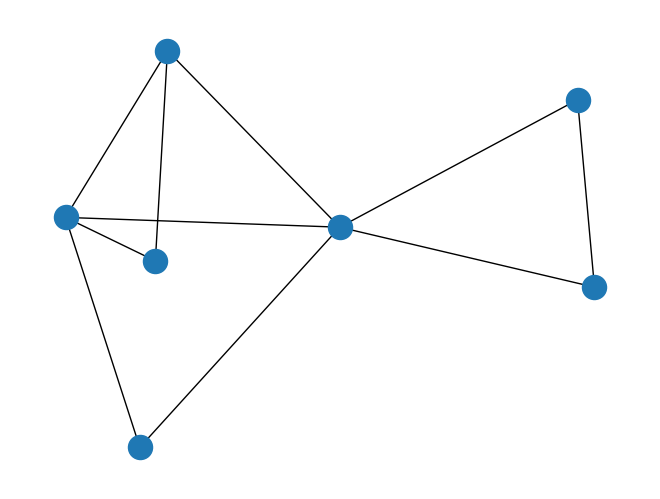

Step: 5


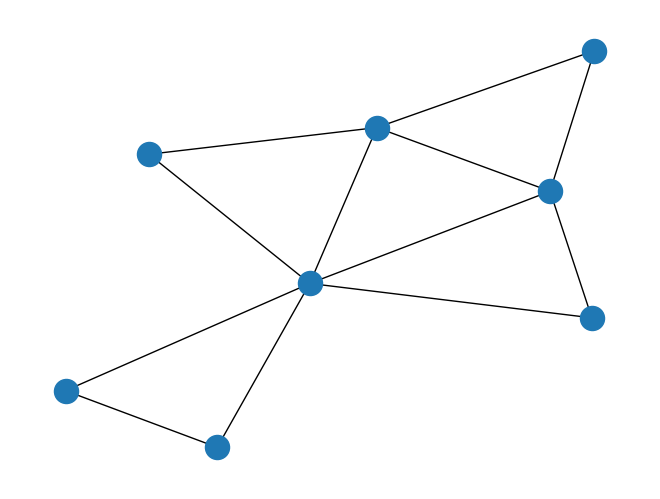

Step: 6


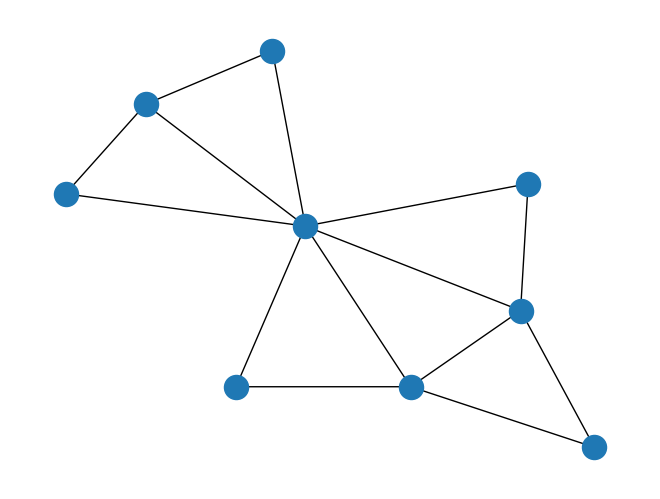

Step: 7


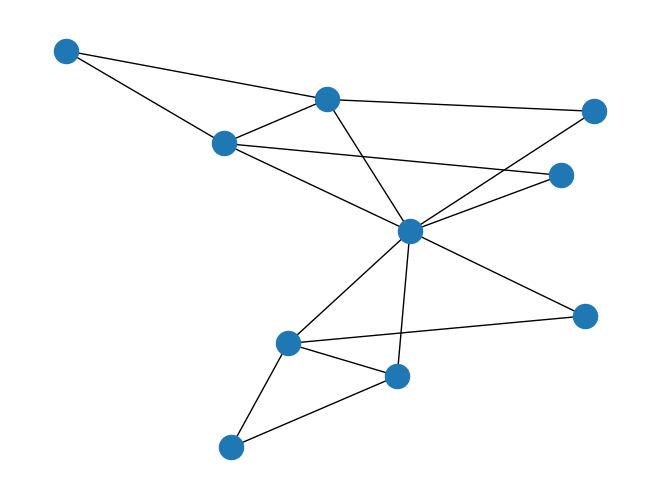

Step: 8


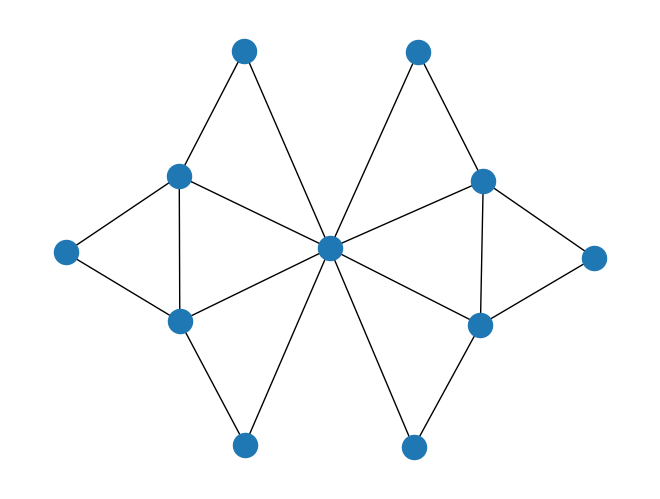

Step: 9


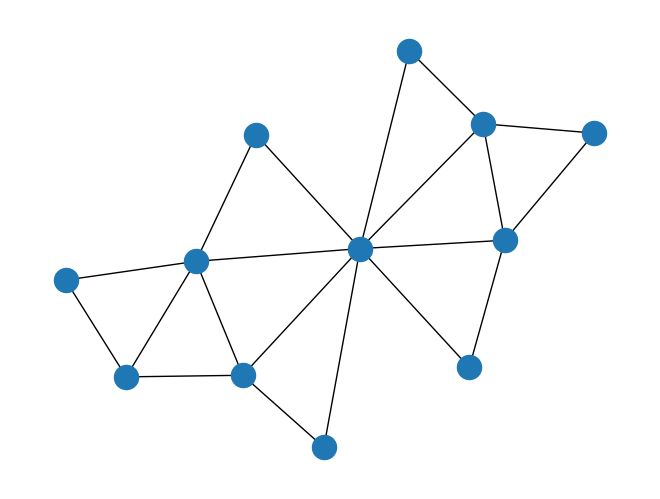

Step: 10


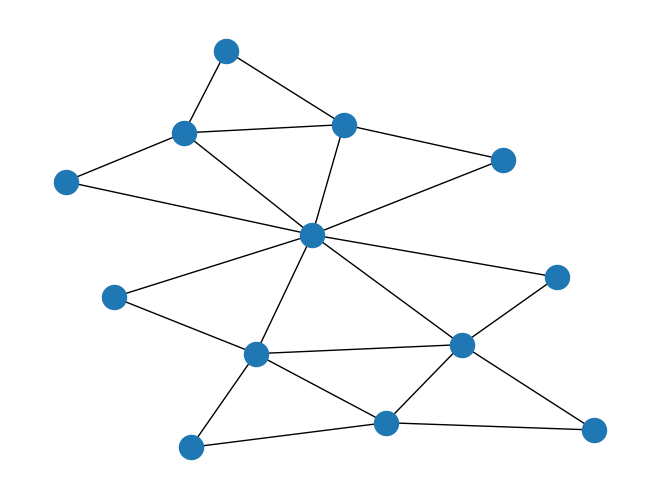

In [ ]:
from itertools import chain
import networkx as nx
import matplotlib.pyplot as plt

ITERATIONS = 10
RULE = ([[0,1]],[[0,2],[2,1],[0,1]])
graph = [[1,2],[2,3]]
next_index = max(chain.from_iterable(graph))+1

def show(graph):
    G = nx.Graph()
    G.add_edges_from(graph)
    nx.draw(G)
    plt.show()

def pattern(rule,list,map):
    pattern = []
    for i,value in enumerate(rule):
        if(value not in map):
            map[value] = list[i]
        pattern.append(map[value])
    return pattern

def rule_check(graph,map={},rule_index=0,indices=[]):
    for i in range(len(graph)):
        if(indices==[]):
            map = {}
        old_map = map.copy()
        if(graph[i]==pattern(RULE[0][rule_index],graph[i],map))and(i not in indices):
            indices.append(i)
            if(rule_index+1==len(RULE[0])):
                return indices,map
            else:
                return rule_check(graph,map,rule_index+1,indices)
        else:
            map = old_map
    else:
        return [],map

print('Initial Graph')
show(graph)
for step in range(ITERATIONS):
    print('Step: ' + str(step+1))
    indices,map = rule_check(graph,indices=[])
    if(indices==[]):
        print('No Matches Found on Step: ' + str(step))
        break
    for i in sorted(indices,reverse=True):
        graph.pop(i)
    for edge in RULE[1]:
        temp = []
        for i in edge:
            if(i not in map):
                map[i] = next_index
                next_index += 1
            temp.append(map[i])
        graph.append(temp)
    show(graph)

Initial Graph


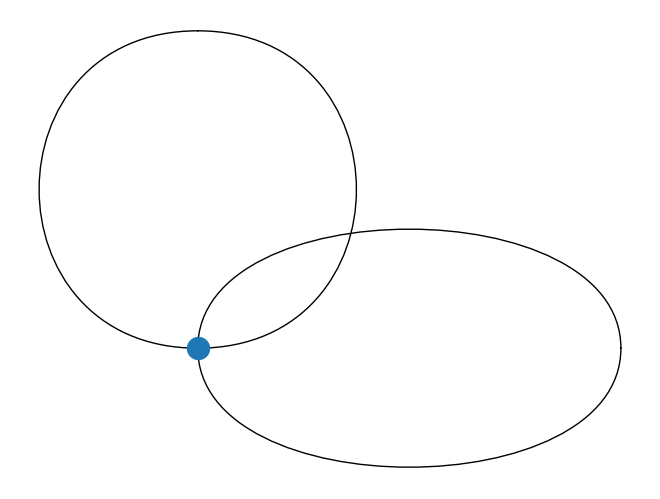

____________________________________________________________________________________________________

Step: 1
[{0: 0, 1: 0, 2: 0}]
[0, 1]


IndexError: list index out of range

In [ ]:
from itertools import chain
import networkx as nx
import matplotlib.pyplot as plt
import sys

ITERATIONS = 10
RULE = ([[0,1]],[[0,1],[2,0],[2,3],[0,3]])
graph = [[0,0]]
next_index = max(chain.from_iterable(graph))+1

def show(graph):
    G = nx.MultiGraph()
    G.add_edges_from(graph)
    nx.draw(G,node_size=1e3/len(list(chain.from_iterable(graph))))
    plt.show()

def pattern(rule,list,map):
    pattern = []
    for i,value in enumerate(rule):
        if(value not in map):
            map[value] = list[i]
        pattern.append(map[value])
    return pattern

def rule_check(graph,used_i,map={},rule_index=0,indices=[]):
    for i in range(len(graph)):
        if(indices==[]):
            map = {}
        old_map = map.copy()
        if(graph[i]==pattern(RULE[0][rule_index],graph[i],map))and(i not in used_i):
            indices.append(i)
            used_i.append(i)
            #print(used_i)
            if(rule_index+1==len(RULE[0])):
                return indices,used_i,map
            else:
                return rule_check(graph,used_i,map,rule_index+1,indices)
        else:
            map = old_map
    else:
        return [],[],map

print('Initial Graph')
show(graph)
for step in range(ITERATIONS):
    print('_'*100+'\n\nStep: '+str(step+1))
    indices,used_i,map = rule_check(graph,used_i=[],indices=[])
    save_map = [map.copy()]
    updates = indices.copy()
    while(indices):
        n1,n2,n3 = rule_check(graph,used_i,indices=[])
        if(not n1):
            break
        indices,used_i,map = n1,n2,n3
        save_map.append(map)
        updates.extend(indices)
    if(used_i==[]):
        sys.exit('No Matches Found on Step: ' + str(step))
    print(save_map)
    print(updates)
    for i in sorted(updates,reverse=True):
        graph.pop(i)
        for edge in RULE[1]:
            temp = []
            for e in edge:
                if(e not in save_map[i]):
                    save_map[i][e] = next_index
                    next_index += 1
                temp.append(save_map[i][e])
            graph.append(temp)
    show(graph)

Initial Graph


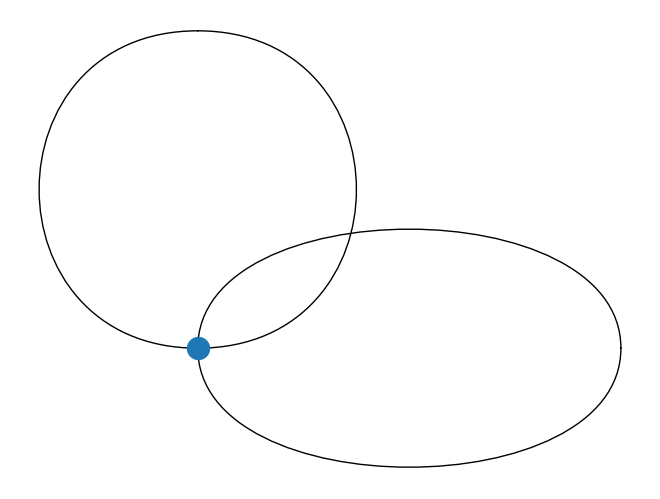

____________________________________________________________________________________________________

Step: 1
[[0, 1]]


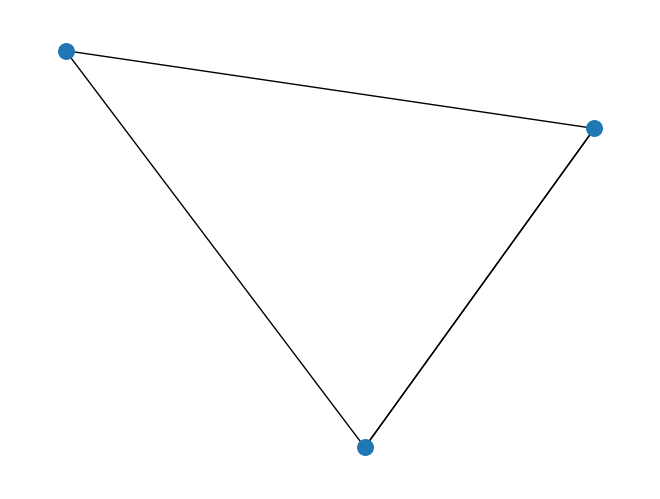

____________________________________________________________________________________________________

Step: 2
[[0, 1]]


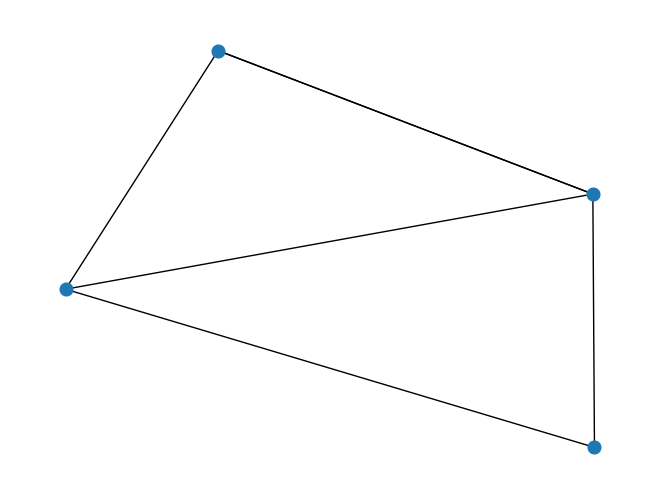

____________________________________________________________________________________________________

Step: 3
[[0, 4]]


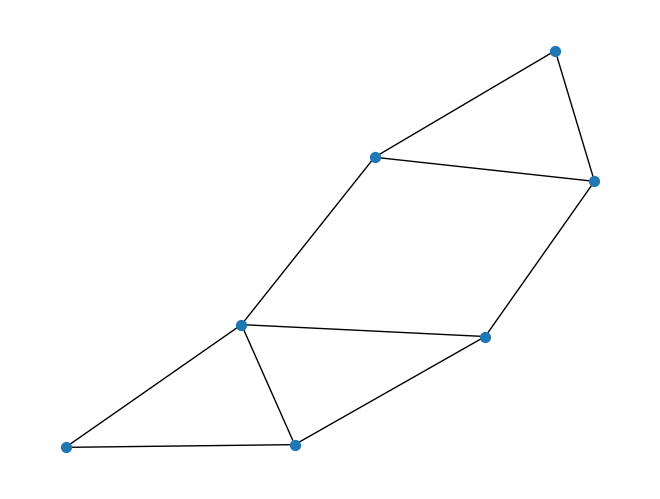

____________________________________________________________________________________________________

Step: 4
[[0, 4]]


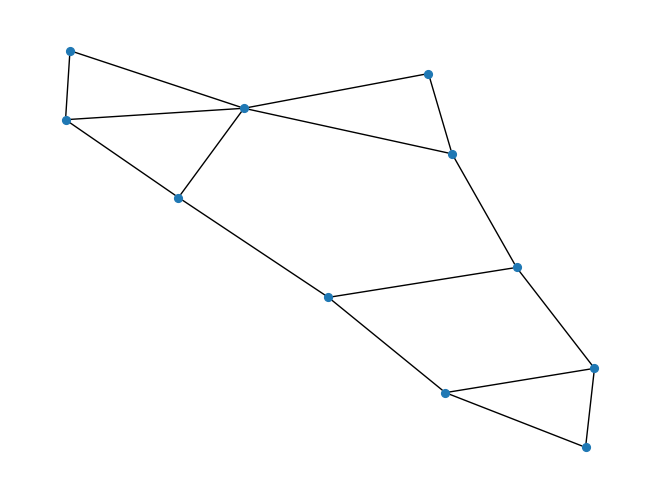

____________________________________________________________________________________________________

Step: 5
[[2, 6]]


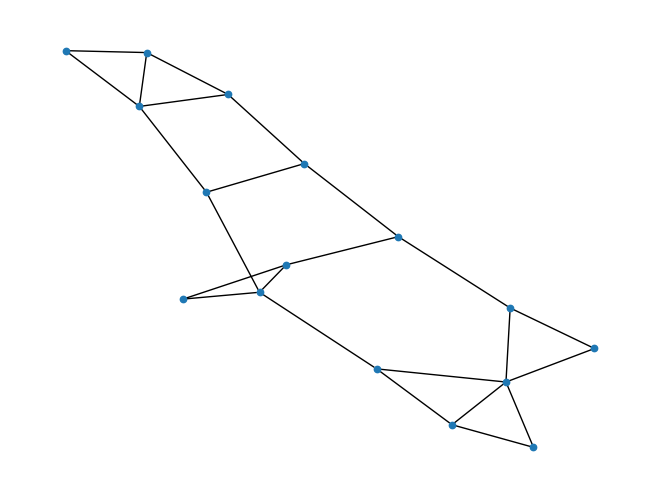

____________________________________________________________________________________________________

Step: 6
[[2, 10]]


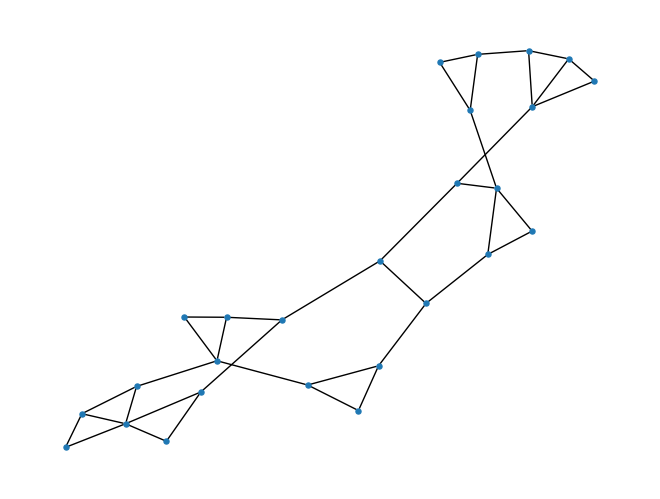

____________________________________________________________________________________________________

Step: 7
[[0, 12]]


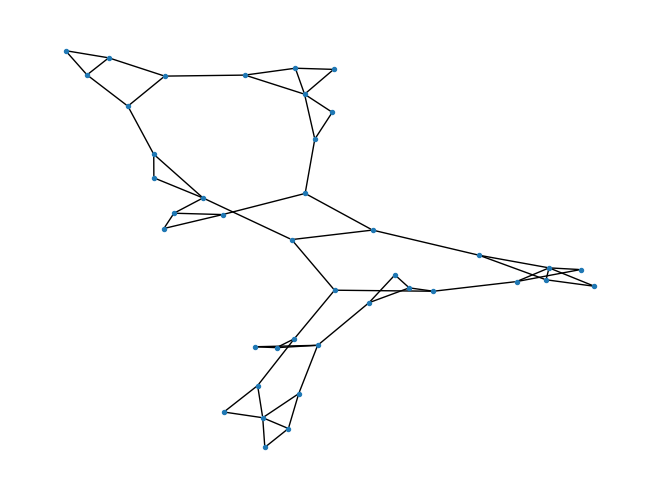

____________________________________________________________________________________________________

Step: 8
[[0, 22]]


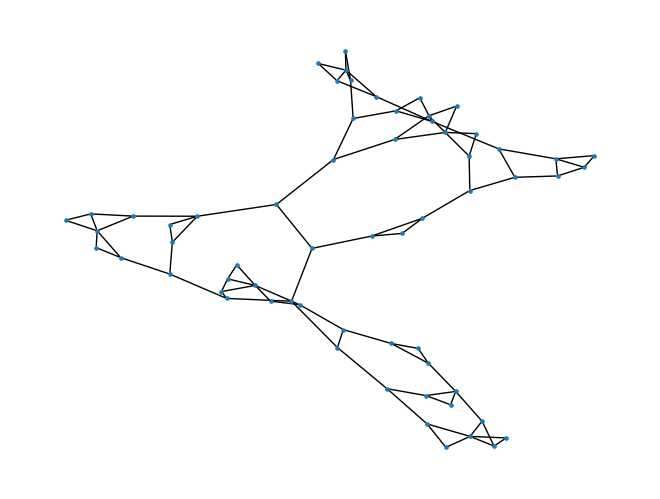

____________________________________________________________________________________________________

Step: 9
[[7, 38]]


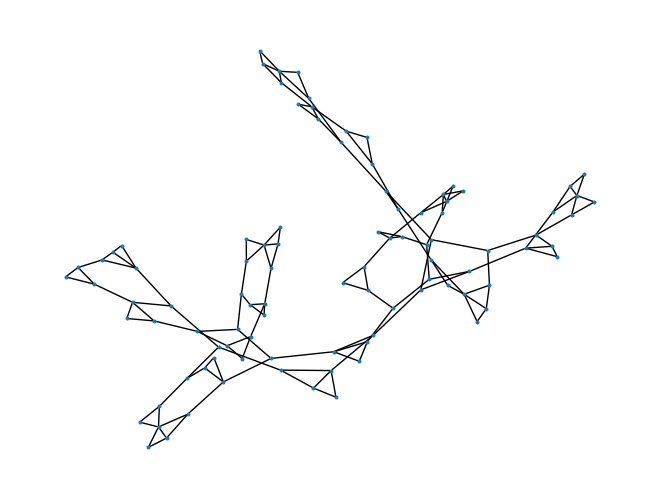

____________________________________________________________________________________________________

Step: 10
[[1, 44]]


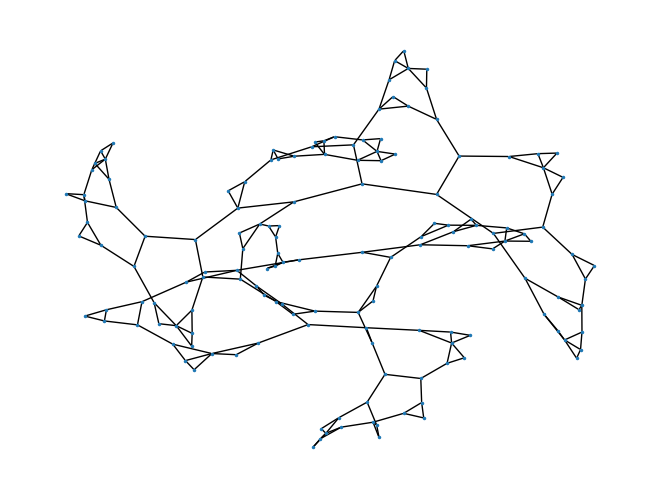

In [23]:
from itertools import chain
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import sys

ITERATIONS = 10
RULE = ([[1,2],[1,3]],[[4,2],[4,5],[2,5],[5,3]])
graph = [[0,0],[0,0]]
next_index = max(chain.from_iterable(graph))+1

def show(graph):
    G = nx.MultiGraph()
    G.add_edges_from(graph)
    nx.draw(G,node_size=1e3/len(list(chain.from_iterable(graph))))
    plt.show()

def pattern(rule,list,map):
    pattern = []
    for i,value in enumerate(rule):
        if(value not in map):
            map[value] = list[i]
        pattern.append(map[value])
    return pattern

def rule_check(graph,used_i,map={},rule_index=0,indices=[],first=True):
    if(not map):
        map = {}
    if(not indices):
        indices = []
    for i in range(len(graph)):
        old_map = map.copy()
        local_indices = indices.copy()
        #print('i '+str(i))
        #print(save_map)
        if(graph[i]==pattern(RULE[0][rule_index],graph[i],map))and(i not in used_i):
            local_indices.append(i)
            used_i.append(i)
            #print(i,'found')
            #print('rule '+str(rule_index))
            if(rule_index+1==len(RULE[0])):
                return local_indices,used_i,map,first
            else:
                n1,n2,n3,new = rule_check(graph,used_i,map,rule_index+1,local_indices,False)
                #print(new)
                if(new):
                    map = old_map
                    continue
                else:
                    return n1,n2,n3,new
        else:
            map = old_map
    else:
        return [],[],map,True


print('Initial Graph')
show(graph)
for step in range(ITERATIONS):
    print('_'*100+'\n\nStep: '+str(step+1))
    indices,used_i,map,first = rule_check(graph,used_i=[],indices=[],map={})
    save_map = [map.copy()]
    updates = [indices.copy()]
    print(updates)
    while(indices):
        n1,n2,n3,first = rule_check(graph,used_i,indices=[],map={})
        if(not n1):
            break
        indices,used_i,map = n1,n2,n3
        save_map.append(map)
        updates.append(indices)
    if(not used_i):
        #print(save_map)
        #print(graph)
        #print(updates)
        sys.exit('No Matches Found on Step: ' + str(step))
    #print(save_map)
    #print(graph)
    #print(updates)
    for u in sorted(np.ndarray.flatten(np.array(updates)),reverse=True):
        graph.pop(u)
    for i in range(len(updates)):
        for edge in RULE[1]:
            temp = []
            for e in edge:
                if(e not in save_map[i]):
                    save_map[i][e] = next_index
                    next_index += 1
                temp.append(save_map[i][e])
            graph.append(temp)
    show(graph)